In [10]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv('hotel_final.csv')

# Preview the data
df.head()

,Unnamed: 0,reviewID,reviewContent,rating,usefulCount,coolCount,funnyCount
0,2982,-ZkzDLAp-6LSdek-nU,My husband took me to stay the night for a fun...,4,0,0,0
1,2983,9yStfyRS5CISu-May43dmA,"stayed at the property over the weekend, got a...",3,0,0,0
2,2984,Wf-7bJszS2n6REXGbrwK2w,"Overall, I think I'm less and less a fan of th...",3,0,0,0
3,2985,ZLe,I'd like to make a confession. I don't really ...,3,21,11,16
4,2986,vURf9AGmThDrRC9TVcQrdw,The good: the view; location The bad: servic...,1,0,0,0


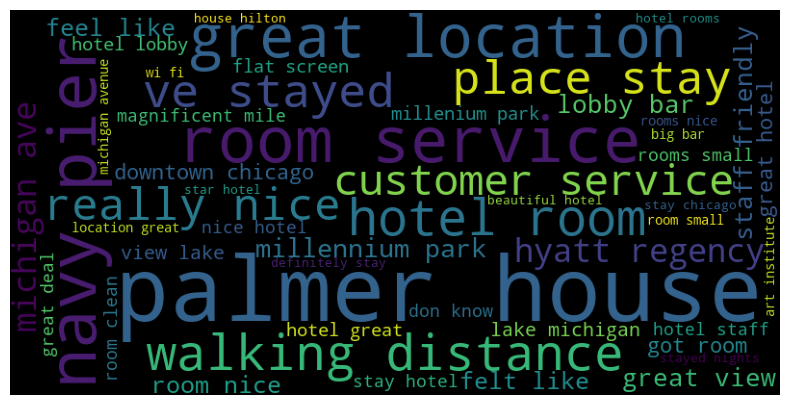

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

reviews = df["reviewContent"].dropna()

# create bigrams
vec = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=50
)

X = vec.fit_transform(reviews)

# get phrase counts
phrase_counts = X.sum(axis=0).A1
phrases = vec.get_feature_names_out()

# create dictionary for wordcloud
freq_dict = dict(zip(phrases, phrase_counts))

# generate word cloud
wc = WordCloud(width=800, height=400).generate_from_frequencies(freq_dict)

# plot
plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [12]:
# define happy vs unhappy
happy = df[df["rating"] >= 4]["reviewContent"].dropna()
unhappy = df[df["rating"] <= 2]["reviewContent"].dropna()

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    max_features=30
)

# happy
X_happy = vec.fit_transform(happy)
happy_counts = X_happy.sum(axis=0).A1
happy_words = vec.get_feature_names_out()

happy_df = pd.DataFrame({
    "phrase": happy_words,
    "happy_count": happy_counts
}).sort_values(by="happy_count", ascending=False)

# unhappy (re-fit vectorizer)
X_unhappy = vec.fit_transform(unhappy)
unhappy_counts = X_unhappy.sum(axis=0).A1
unhappy_words = vec.get_feature_names_out()

unhappy_df = pd.DataFrame({
    "phrase": unhappy_words,
    "unhappy_count": unhappy_counts
}).sort_values(by="unhappy_count", ascending=False)

In [14]:
# merge results
compare_df = pd.merge(happy_df, unhappy_df, on="phrase", how="outer").fillna(0)

# difference column
compare_df["difference"] = compare_df["happy_count"] - compare_df["unhappy_count"]

# sort to see strongest differences
compare_df.sort_values(by="difference", ascending=False).head(15)   # happy-heavy
compare_df.sort_values(by="difference").head(15)                   # unhappy-heavy

,phrase,happy_count,unhappy_count,difference
5,customer service,0.0,21.0,-21.0
42,room small,0.0,13.0,-13.0
9,don know,0.0,12.0,-12.0
34,non smoking,0.0,12.0,-12.0
47,stay hotel,0.0,12.0,-12.0
12,felt like,0.0,12.0,-12.0
44,smoking room,0.0,11.0,-11.0
43,rooms small,0.0,11.0,-11.0
0,20 minutes,0.0,10.0,-10.0
19,hotel lobby,0.0,9.0,-9.0


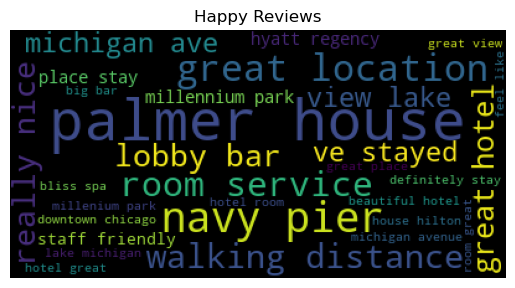

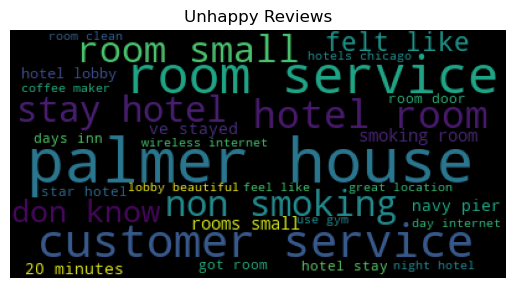

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# happy
wc_happy = WordCloud().generate_from_frequencies(
    dict(zip(happy_df["phrase"], happy_df["happy_count"]))
)

plt.imshow(wc_happy)
plt.title("Happy Reviews")
plt.axis("off")
plt.show()

# unhappy
wc_unhappy = WordCloud().generate_from_frequencies(
    dict(zip(unhappy_df["phrase"], unhappy_df["unhappy_count"]))
)

plt.imshow(wc_unhappy)
plt.title("Unhappy Reviews")
plt.axis("off")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# create binary label
df["sentiment_label"] = df["rating"].apply(lambda x: 1 if x >= 4 else 0)

# split
X_train, X_test, y_train, y_test = train_test_split(
    df["reviewContent"], df["sentiment_label"], test_size=0.2, random_state=42
)

# vectorize
tfidf = TfidfVectorizer(stop_words="english")
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# train model
model = LogisticRegression()
model.fit(X_train_vec, y_train)

# predict sentiment
df["predicted_sentiment"] = model.predict(tfidf.transform(df["reviewContent"]))

In [17]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# split reviews based on model predictions
happy_reviews = df[df["predicted_sentiment"] == 1]["reviewContent"].dropna()
unhappy_reviews = df[df["predicted_sentiment"] == 0]["reviewContent"].dropna()

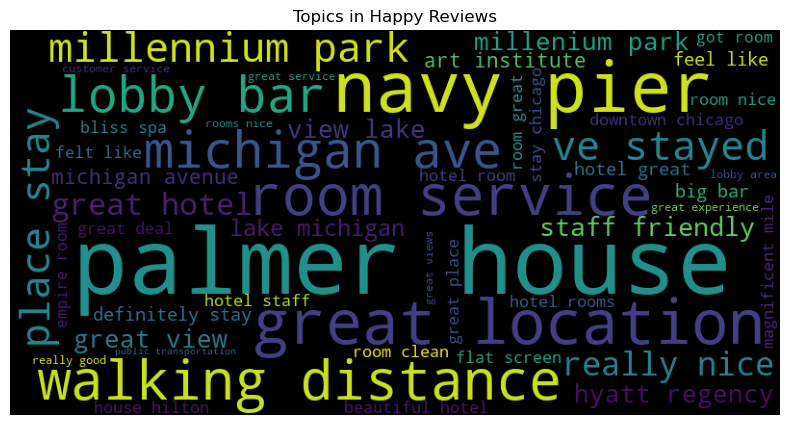

In [18]:
vec_happy = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=50
)

X_happy = vec_happy.fit_transform(happy_reviews)

happy_freq = dict(zip(
    vec_happy.get_feature_names_out(),
    X_happy.sum(axis=0).A1
))

wc_happy = WordCloud(width=800, height=400).generate_from_frequencies(happy_freq)

plt.figure(figsize=(10, 5))
plt.imshow(wc_happy)
plt.title("Topics in Happy Reviews")
plt.axis("off")
plt.show()

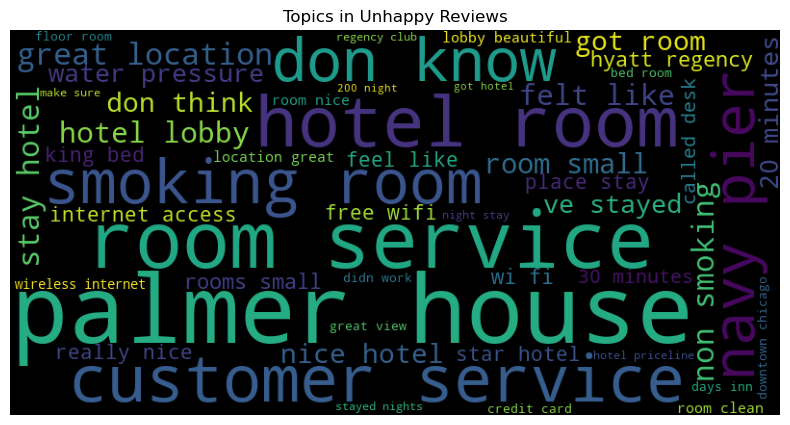

In [19]:
vec_unhappy = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=50
)

X_unhappy = vec_unhappy.fit_transform(unhappy_reviews)

unhappy_freq = dict(zip(
    vec_unhappy.get_feature_names_out(),
    X_unhappy.sum(axis=0).A1
))

wc_unhappy = WordCloud(width=800, height=400).generate_from_frequencies(unhappy_freq)

plt.figure(figsize=(10, 5))
plt.imshow(wc_unhappy)
plt.title("Topics in Unhappy Reviews")
plt.axis("off")
plt.show()

In [20]:
import matplotlib.pyplot as plt

In [25]:
# Happy reviews
vectorizer = CountVectorizer(stop_words="english", ngram_range=(2, 2))

X_happy = vectorizer.fit_transform(happy_reviews.fillna(""))

happy_counts = X_happy.sum(axis=0).A1
happy_phrases = vectorizer.get_feature_names_out()

happy_bigrams = pd.Series(happy_counts, index=happy_phrases).sort_values(ascending=False)

print("Top 5 Happy Bigrams:")
print(happy_bigrams.head(5))

Top 5 Happy Bigrams:
palmer house        124
navy pier            67
great location       51
room service         41
walking distance     39
dtype: int64


In [26]:
# Unhappy reviews
vectorizer = CountVectorizer(stop_words="english", ngram_range=(2, 2))

X_unhappy = vectorizer.fit_transform(unhappy_reviews.fillna(""))

unhappy_counts = X_unhappy.sum(axis=0).A1
unhappy_phrases = vectorizer.get_feature_names_out()

unhappy_bigrams = pd.Series(unhappy_counts, index=unhappy_phrases).sort_values(ascending=False)

print("Top 5 Unhappy Bigrams:")
print(unhappy_bigrams.head(5))

Top 5 Unhappy Bigrams:
palmer house        57
room service        37
hotel room          29
customer service    24
smoking room        21
dtype: int64


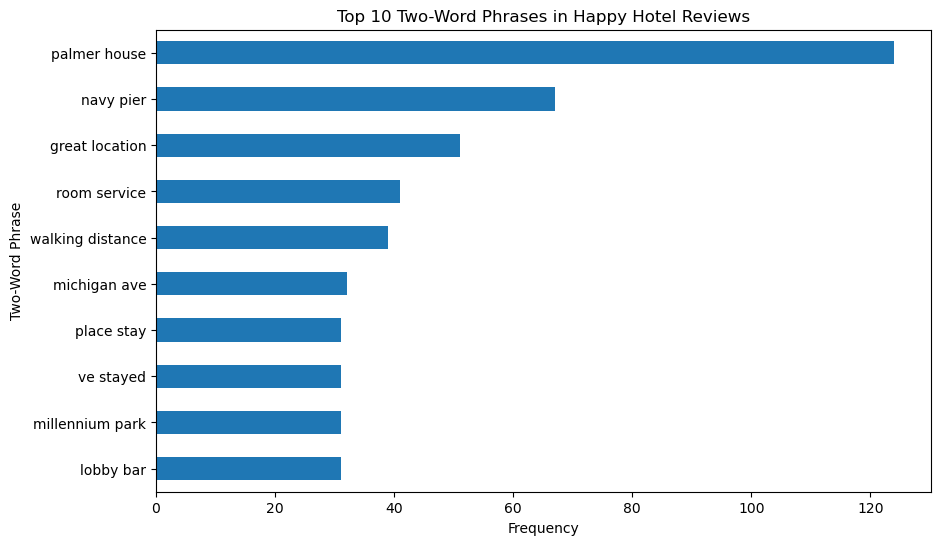

In [27]:
# Top 10 happy bigrams
top10_happy = happy_bigrams.head(10).sort_values()

plt.figure(figsize=(10, 6))
top10_happy.plot(kind="barh")
plt.title("Top 10 Two-Word Phrases in Happy Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Two-Word Phrase")
plt.show()

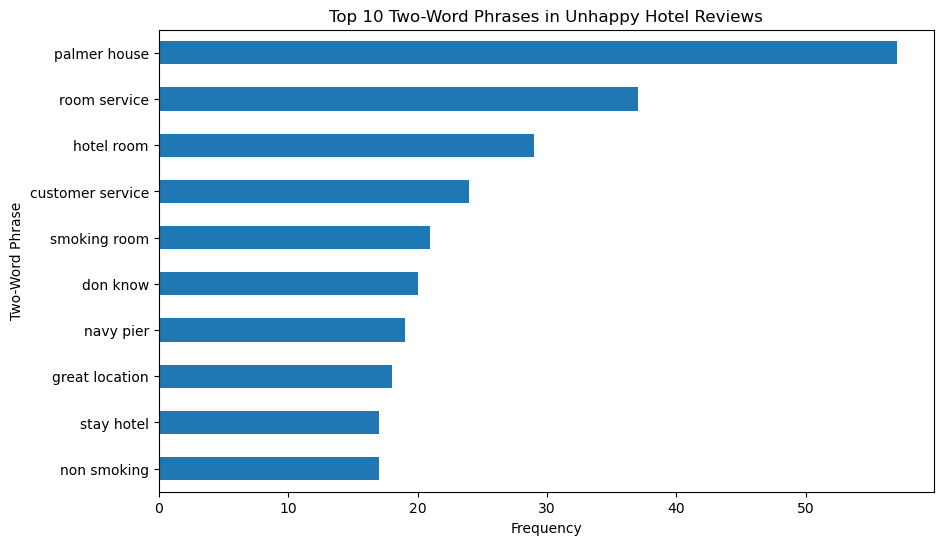

In [28]:
# Top 10 unhappy bigrams
top10_unhappy = unhappy_bigrams.head(10).sort_values()

plt.figure(figsize=(10, 6))
top10_unhappy.plot(kind="barh")
plt.title("Top 10 Two-Word Phrases in Unhappy Hotel Reviews")
plt.xlabel("Frequency")
plt.ylabel("Two-Word Phrase")
plt.show()